In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, f1_score,recall_score,precision_score, classification_report,confusion_matrix


In [3]:
X_train = joblib.load("../data/processed/X_train.pkl")
X_val = joblib.load("../data/processed/X_val.pkl")
X_test = joblib.load("../data/processed/X_test.pkl")

y_train = joblib.load("../data/processed/y_train.pkl")
y_val = joblib.load("../data/processed/y_val.pkl")
y_test = joblib.load("../data/processed/y_test.pkl")

In [4]:
label_encoder = joblib.load("../models/disease_label_encoder.pkl")
model = load_model("../models/multi_disease_ann.h5")

print("Data loaded successfully.")

Data loaded successfully.


In [5]:
y_pred_probs = model.predict(
    X_test
)

1185/1185 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [6]:
y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

print("Prediction shape:", y_pred.shape)
print("Probability shape:", y_pred_probs.shape)

Prediction shape: (37900,)
Probability shape: (37900, 659)


In [7]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred,average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted",zero_division=0)


print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.8308
Precision : 0.8605
Recall    : 0.8308
F1 Score  : 0.8372


In [8]:
macro_precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall   : {macro_recall:.4f}")
print(f"Macro F1       : {macro_f1:.4f}")

Macro Precision: 0.7906
Macro Recall   : 0.7641
Macro F1       : 0.7581


In [9]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                                                          precision    recall  f1-score   support

                                            Rare Disease       0.33      0.06      0.10        18
                               abdominal aortic aneurysm       1.00      1.00      1.00         8
                                        abdominal hernia       0.96      0.92      0.94        53
                                         abscess of nose       0.68      0.83      0.75        30
                                     abscess of the lung       1.00      1.00      1.00         1
                                  abscess of the pharynx       0.83      0.91      0.87        33
                                    acanthosis nigricans       0.50      0.50      0.50         2
                                               acariasis       0.40      1.00      0.57         2
                                               achalasia       0.33      0.20      0.25         5
                   

In [10]:
def top_k_accuracy(y_true, y_prob, k):
    top_k_predictions = np.argsort(
        y_prob,
        axis=1
    )[:, -k:]

    return np.mean([
        true_label in predictions
        for true_label, predictions
        in zip(y_true, top_k_predictions)
    ])


top_1 = top_k_accuracy(
    y_test,
    y_pred_probs,
    1
)

top_3 = top_k_accuracy(
    y_test,
    y_pred_probs,
    3
)

top_5 = top_k_accuracy(
    y_test,
    y_pred_probs,
    5
)

print(f"Top-1 Accuracy: {top_1 * 100:.2f}%")
print(f"Top-3 Accuracy: {top_3 * 100:.2f}%")
print(f"Top-5 Accuracy: {top_5 * 100:.2f}%")

Top-1 Accuracy: 83.08%
Top-3 Accuracy: 94.64%
Top-5 Accuracy: 97.20%


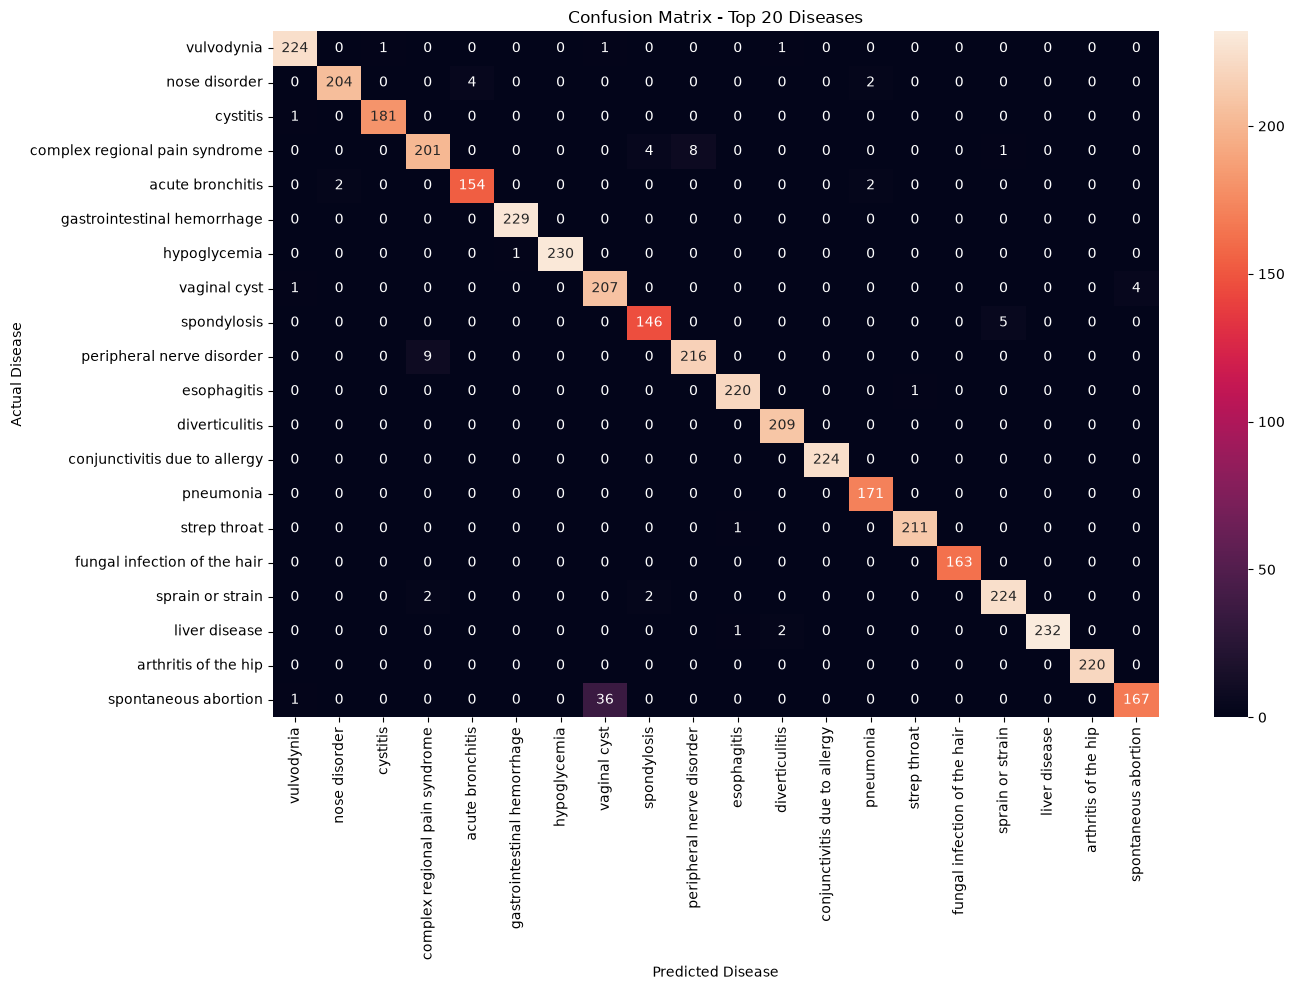

In [13]:
# Find the 20 most frequent disease classes in test data
top_20_classes = (
    pd.Series(y_test)
    .value_counts()
    .head(20)
    .index
)

# Create confusion matrix
cm_top20 = confusion_matrix(
    y_test,
    y_pred,
    labels=top_20_classes
)

# Convert encoded labels to disease names
top_20_names = label_encoder.inverse_transform(
    top_20_classes
)

# Plot
plt.figure(figsize=(14, 10))

sns.heatmap(
    cm_top20,
    annot=True,
    fmt="d",
    xticklabels=top_20_names,
    yticklabels=top_20_names
)

plt.title("Confusion Matrix - Top 20 Diseases")
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()